In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
import plotly.express as px

In [2]:
df = pd.read_csv("ExoplanetArchiveAllClean.csv")
df.head()

/tmp/ipykernel_1254283/3107483945.py:1: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("ExoplanetArchiveAllClean.csv")


,rowid,pl_name,hostname,pl_letter,hd_name,hip_name,tic_id,gaia_dr2_id,gaia_dr3_id,default_flag,...,rowupdate,pl_pubdate,releasedate,pl_nnotes,st_nphot,st_nrvc,st_nspec,pl_nespec,pl_ntranspec,pl_ndispec
0,1,11 Com b,11 Com,b,HD 107383,HIP 60202,TIC 72437047,Gaia DR2 3946945413106333696,Gaia DR3 3946945413106333696,1,...,9/19/2023,2023-12,9/19/2023,2,1,2,0,0,0,0
1,2,11 Com b,11 Com,b,HD 107383,HIP 60202,TIC 72437047,Gaia DR2 3946945413106333696,Gaia DR3 3946945413106333696,0,...,7/23/2014,2011-08,7/23/2014,2,1,2,0,0,0,0
2,3,11 Com b,11 Com,b,HD 107383,HIP 60202,TIC 72437047,Gaia DR2 3946945413106333696,Gaia DR3 3946945413106333696,0,...,5/14/2014,2008-01,5/14/2014,2,1,2,0,0,0,0
3,4,11 UMi b,11 UMi,b,HD 136726,HIP 74793,TIC 230061010,Gaia DR2 1696798367260229376,Gaia DR3 1696798367260229376,0,...,4/25/2018,2011-08,7/23/2014,0,1,1,0,0,0,0
4,5,11 UMi b,11 UMi,b,HD 136726,HIP 74793,TIC 230061010,Gaia DR2 1696798367260229376,Gaia DR3 1696798367260229376,0,...,4/25/2018,2009-10,5/14/2014,0,1,1,0,0,0,0


Note: default_flag is 1 for the accepted values of a planet and 0 for all other values of a planet, filter by default_flag==1 to get one of each planet

In [3]:
# Filter to have one of each planet
df = df.drop(df[df.default_flag == 1].index)

In [4]:
len(df["pl_rade"].dropna()) / len(df["pl_rade"])

0.6791698968334426

In [5]:
# GET TARGET (RADIUS)
df = df.dropna(subset=['pl_rade'])

y = np.log10(df["pl_rade"])
df = df.drop(["pl_rade", "pl_radj"], axis=1)

In [6]:
# PREPROCESS MASS DATA

mass_column_names = ['pl_masse',
 'pl_masseerr1',
 'pl_masseerr2',
 'pl_masselim',
 'pl_massj',
 'pl_massjerr1',
 'pl_massjerr2',
 'pl_massjlim',
 'pl_msinie',
 'pl_msinieerr1',
 'pl_msinieerr2',
 'pl_msinielim',
 'pl_msinij',
 'pl_msinijerr1',
 'pl_msinijerr2',
 'pl_msinijlim',
 'pl_cmasse',
 'pl_cmasseerr1',
 'pl_cmasseerr2',
 'pl_cmasselim',
 'pl_cmassj',
 'pl_cmassjerr1',
 'pl_cmassjerr2',
 'pl_cmassjlim',
 'pl_bmasse',
 'pl_bmasseerr1',
 'pl_bmasseerr2',
 'pl_bmasselim',
 'pl_bmassj',
 'pl_bmassjerr1',
 'pl_bmassjerr2',
 'pl_bmassjlim',
 'pl_bmassprov',
 'pl_dens']

mass_columns = {"Mass":"pl_masse", "Msini":"pl_msinie", "Msin(i)/sin(i)":"pl_cmasse"}

mass = []
mass_error_width = []
mass_type = []

for i, row in df.iterrows():
    t = row["pl_bmassprov"]
    if t in mass_columns:
        m = row[mass_columns[t]]
        merr1 = row[mass_columns[t] + "err1"]
        merr2 = row[mass_columns[t] + "err2"]
        
        mass.append(m)
        mass_type.append(t)
        mass_error_width.append(abs(merr1)+abs(merr2))
    else:
        mass.append(np.NaN)
        mass_type.append(np.NaN)
        mass_error_width.append(np.NaN)

df["pl_mass"] = mass
df["pl_mass_type"] = mass_type

df = df.drop(mass_column_names, axis=1)

In [7]:
to_drop = ['default_flag', "pl_letter", "sy_mnum"]
for s in df.columns:
    if s.endswith("err1") or s.endswith("err2") or s.endswith("lim") or s.endswith("name") or s.endswith("id"):
        to_drop.append(s)
    if s in ['rv_flag', 'pul_flag', 'ptv_flag', 'tran_flag','ast_flag','obm_flag','micro_flag','etv_flag','ima_flag','dkin_flag']: # duplicates from discovery method
        to_drop.append(s)
X = df.drop(to_drop, axis=1)

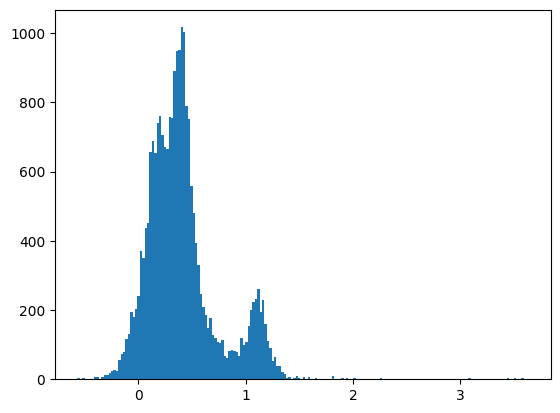

In [8]:
plt.hist(y, bins="auto")
plt.show()

In [9]:
len(y)

22778

In [10]:
b = y.mean()
MSE = ((y - b)**2).mean()
print("b =", b)
print("MSE =", MSE)

b = 0.40951494843017505
MSE = 0.11474705822718231


In [11]:
10**b

2.5675265809335444

In [12]:
cols = list(X.columns)
percent_nan = []

for col in cols:
    percent_nan.append(len(X[col].dropna()) / len(X[col]))

nan_ratio = pd.DataFrame()
nan_ratio["Feature"] = cols
nan_ratio["not NaN"] = percent_nan
nan_ratio = nan_ratio.sort_values("not NaN", ascending=False)
print(nan_ratio.to_string())

            Feature   not NaN
84       pl_ndispec  1.000000
0           sy_snum  1.000000
1           sy_pnum  1.000000
2           cb_flag  1.000000
3   discoverymethod  1.000000
19         ttv_flag  1.000000
76       pl_pubdate  1.000000
75        rowupdate  1.000000
5      disc_pubdate  1.000000
45               ra  1.000000
47              dec  1.000000
46           decstr  1.000000
49             glon  1.000000
50             elat  1.000000
51             elon  1.000000
48             glat  1.000000
10          soltype  1.000000
6       disc_locale  1.000000
7     disc_facility  1.000000
8    disc_telescope  1.000000
11  pl_controv_flag  1.000000
9   disc_instrument  1.000000
77      releasedate  1.000000
44            rastr  1.000000
83     pl_ntranspec  1.000000
82        pl_nespec  1.000000
81         st_nspec  1.000000
80          st_nrvc  1.000000
79         st_nphot  1.000000
78        pl_nnotes  1.000000
4         disc_year  0.999956
58          sy_vmag  0.999649
73        

In [13]:
X_number = X.select_dtypes(include='number')
X_categorical = X.select_dtypes(exclude='number')
X_number.corr()

,sy_snum,sy_pnum,cb_flag,disc_year,pl_controv_flag,pl_orbper,pl_orbsmax,pl_orbeccen,pl_insol,pl_eqt,...,sy_tmag,sy_kepmag,pl_nnotes,st_nphot,st_nrvc,st_nspec,pl_nespec,pl_ntranspec,pl_ndispec,pl_mass
sy_snum,1.000000,0.071084,0.069047,-0.135383,-0.011425,-0.001461,-0.000763,0.116229,0.092682,0.107527,...,-0.285543,-0.271582,0.538952,0.184754,0.239489,0.065620,0.224191,0.105941,0.000298,0.075389
sy_pnum,0.071084,1.000000,-0.006459,-0.283150,0.028399,-0.005565,-0.006448,-0.001296,-0.079282,-0.158292,...,-0.033476,-0.075108,0.190615,-0.065095,-0.033200,0.055684,-0.061541,-0.017705,0.016729,-0.180706
cb_flag,0.069047,-0.006459,1.000000,0.016844,-0.000953,0.004408,0.015532,0.080107,-0.002057,-0.004525,...,-0.023110,0.007457,0.030926,-0.002128,-0.003507,-0.001190,-0.002598,-0.002857,0.065314,0.114260
disc_year,-0.135383,-0.283150,0.016844,1.000000,-0.016206,0.010565,0.013355,-0.071630,-0.015793,-0.065188,...,-0.061338,0.055871,-0.497345,-0.287818,-0.375872,-0.143667,-0.285414,-0.180065,-0.032580,-0.148043
pl_controv_flag,-0.011425,0.028399,-0.000953,-0.016206,1.000000,-0.000320,-0.000315,0.002383,-0.005724,-0.020308,...,-0.049733,-0.052750,0.050024,-0.004617,-0.007609,-0.002581,-0.005636,-0.006198,-0.000829,-0.026900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
st_nspec,0.065620,0.055684,-0.001190,-0.143667,-0.002581,-0.000408,-0.000507,0.127314,0.004693,0.028431,...,-0.219092,NaN,0.161425,0.270762,0.483329,1.000000,0.415847,0.233323,-0.001035,-0.006179
pl_nespec,0.224191,-0.061541,-0.002598,-0.285414,-0.005636,-0.000917,-0.001224,0.116039,0.161339,0.232015,...,-0.259023,-0.123581,0.322829,0.474768,0.499778,0.415847,1.000000,0.457346,-0.002260,0.179030
pl_ntranspec,0.105941,-0.017705,-0.002857,-0.180065,-0.006198,-0.000982,-0.001236,0.080703,0.042413,0.074289,...,-0.212893,-0.204929,0.161912,0.255138,0.267998,0.233323,0.457346,1.000000,-0.002486,-0.042125
pl_ndispec,0.000298,0.016729,0.065314,-0.032580,-0.000829,0.249253,0.197391,0.114272,NaN,0.022671,...,-0.074055,NaN,0.056474,0.002444,-0.001739,-0.001035,-0.002260,-0.002486,1.000000,0.220188


In [14]:
X_number.columns

Index(['sy_snum', 'sy_pnum', 'cb_flag', 'disc_year', 'pl_controv_flag',
       'pl_orbper', 'pl_orbsmax', 'pl_orbeccen', 'pl_insol', 'pl_eqt',
       'pl_orbincl', 'ttv_flag', 'pl_imppar', 'pl_trandep', 'pl_trandur',
       'pl_ratdor', 'pl_ratror', 'pl_occdep', 'pl_orbtper', 'pl_orblper',
       'pl_rvamp', 'pl_projobliq', 'pl_trueobliq', 'st_teff', 'st_rad',
       'st_mass', 'st_met', 'st_lum', 'st_logg', 'st_age', 'st_dens',
       'st_vsin', 'st_rotp', 'st_radv', 'ra', 'dec', 'glat', 'glon', 'elat',
       'elon', 'sy_pm', 'sy_pmra', 'sy_pmdec', 'sy_dist', 'sy_plx', 'sy_bmag',
       'sy_vmag', 'sy_jmag', 'sy_hmag', 'sy_kmag', 'sy_umag', 'sy_gmag',
       'sy_rmag', 'sy_imag', 'sy_zmag', 'sy_w1mag', 'sy_w2mag', 'sy_w3mag',
       'sy_w4mag', 'sy_gaiamag', 'sy_icmag', 'sy_tmag', 'sy_kepmag',
       'pl_nnotes', 'st_nphot', 'st_nrvc', 'st_nspec', 'pl_nespec',
       'pl_ntranspec', 'pl_ndispec', 'pl_mass'],
      dtype='object')

In [15]:
Xs = X[['pl_orbper', 'pl_orbsmax', 'pl_orbeccen', 'pl_insol', 'pl_eqt', 'pl_orbincl']].copy()
Xs["y"] = y
Xs = Xs.dropna()
ys = Xs["y"]
Xs = Xs.drop("y", axis=1)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(Xs, ys, test_size=0.2, random_state=0)

In [17]:
stnd = StandardScaler().set_output(transform='pandas')
X_train = stnd.fit_transform(X_train)
X_test = stnd.transform(X_test)

In [18]:
grid = {"n_neighbors": np.arange(100)+1}

knn = KNeighborsRegressor()

knnCV = GridSearchCV(knn, grid,return_train_score=True, n_jobs=-1)
knnCV.fit(X_train, y_train)

knn_results = pd.DataFrame()
knn_results['n_neighbors'] = grid['n_neighbors']
knn_results['train R2'] = knnCV.cv_results_['mean_train_score']
knn_results['valid R2']  = knnCV.cv_results_['mean_test_score']

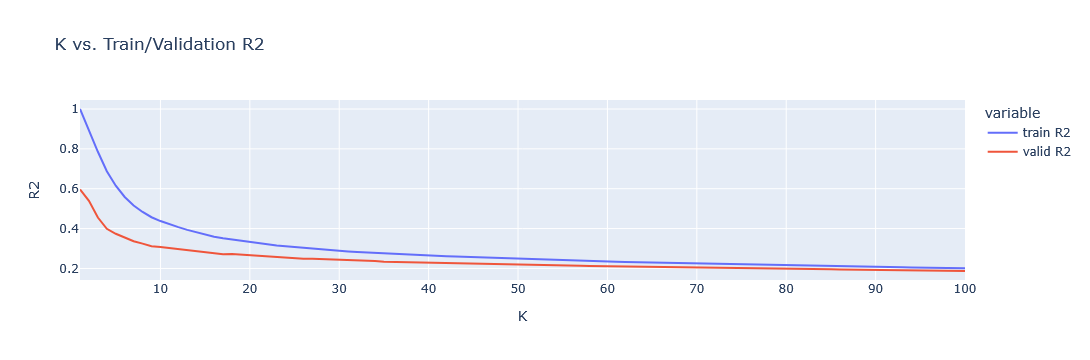

In [19]:
# Plot neighbors against train/valid error
fig = px.line(
    knn_results,
    x='n_neighbors',
    y=['train R2', 'valid R2'],
    labels={'value': 'R2', 'n_neighbors': 'K'},
    title='K vs. Train/Validation R2',
)
fig.show()

In [23]:
print("Best Estimator:", knnCV.best_estimator_)
print("Train R2", knnCV.score(X_train, y_train))
print("Valid R2", knnCV.best_score_)
print("Test R2", knnCV.score(X_test, y_test))

Best Estimator: KNeighborsRegressor(n_neighbors=1)
Train R2 1.0
Valid R2 0.5966997362675551
Test R2 0.6862205066607352


In [24]:
MSE_train = ((knnCV.predict(X_train) - y_train)**2).mean()
MSE_test = ((knnCV.predict(X_test) - y_test)**2).mean()

print("Train MSE", MSE_train)
print("Test MSE", MSE_test)

Train MSE 0.0
Test MSE 0.03160214248083239
